# Lab 1: weather data, climatologies, and the persistence forecast

This lab builds familiarity with ERA5 as an xarray object: how the reanalysis is stored, how a climatology and an anomaly are computed from it, how much a field changes from one time step to the next, and how a forecast is verified against it.
The forecast we verify is the simplest one, persistence, and the verification code you write for it is the code that verifies every model you train later.

The notebook asks questions and names the objects each answer produces (their name, dimensions, and units), and it gives no solution code.
Work through the sections in order, since each opens on an object the previous one produced.
Every plot and number in it is asked for a reason: on each one, say why you are looking at it and what it tells you, rather than only producing it.

Keep the objects you build (`data`, the climatologies, the statistics, and the verification functions), because the next lab starts from them.

## Setup

The imports below are the whole toolkit for this lab.
xarray carries the data with named dimensions and coordinates, and inside it every transpose and reduction is by name already.
numpy is for the moments where you leave xarray, einops for naming the axes of a numpy array or a tensor when you do, and matplotlib is used through xarray's own `.plot` methods wherever it can be.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

xr.set_options(keep_attrs=True, display_expand_data=False)

### Documentation

xarray

- [Dataset](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html) and [DataArray](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html): the two objects you work with here.
- [Indexing and selecting](https://docs.xarray.dev/en/stable/user-guide/indexing.html): `.sel` by coordinate value and `.isel` by position.
- [groupby](https://docs.xarray.dev/en/stable/user-guide/groupby.html): split, apply, and combine over a coordinate such as `time.dayofyear`.
- [diff](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.diff.html): the difference along one dimension.
- [rolling](https://docs.xarray.dev/en/stable/user-guide/computation.html#rolling-window-operations): windowed reductions along one dimension.
- [Plotting](https://docs.xarray.dev/en/stable/user-guide/plotting.html): `.plot()` picks a line, a histogram, or a map from the dimensions of the array.

Data

- [WeatherBench 2 data guide](https://weatherbench2.readthedocs.io/en/latest/data-guide.html): every store below, its grid, and its variables.
- [ARCO-ERA5](https://github.com/google-research/arco-era5): the native-resolution ERA5 archive that is updated continuously.

### Data stores

All data live in public Google Cloud buckets and open with `xr.open_zarr` and anonymous access.
Opening is lazy: nothing downloads until you `.load()`, `.plot()`, or read `.values`.

- `era5_5p6` and `era5_1p5`: ERA5 1959 to 2023-01-10 at 6-hourly cadence, on a 64 by 32 grid (5.625 degrees) and a 240 by 121 grid (1.5 degrees), 13 pressure levels.
- `clim_5p6` and `clim_1p5`: the WeatherBench 2 climatology on the same two grids, 1990 to 2019, with dimensions `hour` and `dayofyear`.
  At 5.625 degrees one chunk is the whole `(hour, dayofyear)` block of a variable, and for a level variable the whole column, so one level of the climatology costs about 150 MB of download; take it once.
- `hres_5p6` and `hres_1p5`: the ECMWF HRES forecasts 2016 to 2022 initialised at 00 and 12 UTC, with dimensions `time` (initialisation) and `prediction_timedelta` (lead) out to 10 days.
- `arco`: ERA5 at its native 0.25 degree, hourly, 37 levels, updated to about a week ago; the recent week is the only part of it we use, and section 7 says why.
  Each hour is one chunk of the whole globe (about 2 MB compressed, 4 MB in memory), so a week of one variable is 168 chunks, and a time series at one point costs the same download as the globe.

The unit of download is the store's chunk.
At 5.625 degrees a chunk holds 100 time steps and, for a variable with levels, all 13 levels, so selecting one level costs the same download as the whole column.
Five years of the nine variables below is about 550 MB in memory, and about 3 GB of download when the level variables come with their full column.
Load once, cache what you loaded (`to_netcdf` or `to_zarr`), and reopen the cache after that.
The 1.5 degree store is 14 times larger per field; keep it lazy and select before you load.

In [2]:
ANON = {"token": "anon"}

STORES = {
    "era5_5p6": "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr",
    "era5_1p5": "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr",
    "clim_5p6": "gs://weatherbench2/datasets/era5-hourly-climatology/1990-2019_6h_64x32_equiangular_conservative.zarr",
    "clim_1p5": "gs://weatherbench2/datasets/era5-hourly-climatology/1990-2019_6h_240x121_equiangular_with_poles_conservative.zarr",
    "hres_5p6": "gs://weatherbench2/datasets/hres/2016-2022-0012-64x32_equiangular_conservative.zarr",
    "hres_1p5": "gs://weatherbench2/datasets/hres/2016-2022-0012-240x121_equiangular_with_poles_conservative.zarr",
    "arco": "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
}

era5 = xr.open_zarr(STORES["era5_5p6"], storage_options=ANON, chunks={})
clim = xr.open_zarr(STORES["clim_5p6"], storage_options=ANON, chunks={})
era5

<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * longitude                                         (longitude) float64 512B ...
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

### Variables

The short names on the left are the ones we use throughout; the right-hand side is the WeatherBench 2 variable name and the pressure level, `None` for a surface variable.
The order of this dictionary is the channel order of every array you build from it.

In [3]:
VARIABLES = {
    "T2M":  ("2m_temperature", None),           # K
    "U10M": ("10m_u_component_of_wind", None),  # m/s
    "V10M": ("10m_v_component_of_wind", None),  # m/s
    "TP6h": ("total_precipitation_6hr", None),  # m, accumulated over the six hours ending at the time stamp
    "Z500": ("geopotential", 500),              # m^2/s^2
    "T850": ("temperature", 850),               # K
    "Q700": ("specific_humidity", 700),         # kg/kg
    "U250": ("u_component_of_wind", 250),       # m/s
    "V250": ("v_component_of_wind", 250),       # m/s
}

PERIOD = slice("2015", "2019")   # five years, inclusive
AUGSBURG = dict(latitude=48.37, longitude=10.90)

## 1. What is in the store, and how do we look at it?

**1.1**
What does the repr of `era5` tell you about the size of the store, its coordinates, and its chunking?
Which variables carry a `level` dimension, in which order do the dimensions of a variable come, and how are the latitude and longitude coordinates ordered and spaced?
Where does the longitude coordinate start and end?

In [4]:
# --- 1.1 What does the repr of era5 tell us? ---
# The store has dimensions (time, latitude, longitude) for surface variables,
# and adds a "level" dimension for pressure-level variables.
# Latitude runs from -87.19 to 87.19 (cell centres, equiangular).
# Longitude runs from 0 to 354.375 in steps of 5.625 degrees.
# Variables with levels: temperature, geopotential, specific_humidity,
# u_component_of_wind, v_component_of_wind.


**1.2**
How do we build `data`, a Dataset with the nine variables of `VARIABLES` as data variables named by their short keys, over `PERIOD`, with dimensions `(time, latitude, longitude)` and loaded into memory?
Which xarray call selects a period from year strings, which selects a level and drops the coordinate, and which puts the dimensions in the order named above?
How large is `data` in memory (`data.nbytes`), how long did the load take, and where do you save it so that you never load it twice?



In [ ]:

# --- 1.2 Build data from the GCS store ---
# era5 is already open (from cell above).  We select the nine variables
# over 2015-2019.  For level variables we select the level and drop
# the level coordinate so that all variables share (time, latitude, longitude).
data = xr.Dataset()
for short, (wb_name, level) in VARIABLES.items():
    da = era5[wb_name].sel(time=PERIOD)
    if level is not None:
        da = da.sel(level=level).drop_vars("level")
    da = da.transpose("time", "latitude", "longitude")
    data[short] = da
data = data.load()

print("data loaded:", data)
print(f"\nMemory: {data.nbytes / 1e6:.0f} MB")

data = data.to_zarr("data_2015_2019.zarr", zarr_format=2)

data loaded: <xarray.Dataset> Size: 539MB
Dimensions:    (latitude: 32, longitude: 64, time: 7304)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * time       (time) datetime64[ns] 58kB 2015-01-01 ... 2019-12-31T18:00:00
Data variables:
    T2M        (time, latitude, longitude) float32 60MB 245.0 244.8 ... 252.4
    U10M       (time, latitude, longitude) float32 60MB -4.369 -3.912 ... 0.3739
    V10M       (time, latitude, longitude) float32 60MB -3.413 -3.956 ... -1.486
    TP6h       (time, latitude, longitude) float32 60MB 0.0 0.0 ... 0.0001362
    Z500       (time, latitude, longitude) float32 60MB 5.01e+04 ... 4.812e+04
    T850       (time, latitude, longitude) float32 60MB 254.6 254.5 ... 250.7
    Q700       (time, latitude, longitude) float32 60MB 0.0003723 ... 0.0003305
    U250       (time, latitude, longitude) float32 60MB 2.229 2.931 ... 1.476
    V250

**1.3**
What do a `T2M` and a `Z500` field look like at one time step, and what do the units in the attributes say?
Which large-scale structure is visible in each?



In [46]:
data = xr.open_zarr("data_2015_2019.zarr")
data = data.chunk({"time": -1})

In [47]:
print(data["T2M"].dims)
print(data["T2M"].coords)
era5

('time', 'latitude', 'longitude')
Coordinates:
  * time       (time) datetime64[ns] 58kB 2015-01-01 ... 2019-12-31T18:00:00
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4


<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * longitude                                         (longitude) float64 512B ...
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

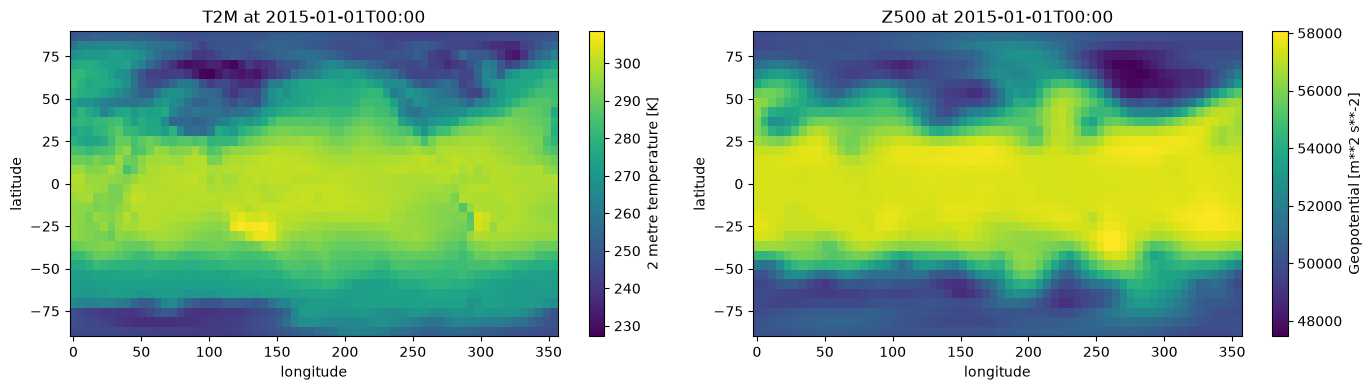

In [48]:
# --- 1.3 One T2M and one Z500 field ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
data["T2M"].isel(time=0).plot(ax=axes[0])
axes[0].set_title(f"T2M at {str(data.time.values[0])[:16]}")
data["Z500"].isel(time=0).plot(ax=axes[1])
axes[1].set_title(f"Z500 at {str(data.time.values[0])[:16]}")
plt.tight_layout()
plt.show()
# T2M: warm at low latitudes, cold at the poles - zonal gradient dominates.
# Z500: large-scale wave pattern (Rossby waves) visible in mid-latitudes.



**1.4**
How do we crop?
`.sel` selects by coordinate value and `.isel` by position: select one year, one day, the 00 UTC time steps only, and Europe (35 to 72 degrees north, 25 degrees west to 45 degrees east).
Look at the longitude coordinate of your Europe crop next to the longitude coordinate of the store, and say why the crop needs care where the coordinate wraps.
Plot a European `T2M` map for one day of the 2019 heat wave (25 July 2019).



Europe crop: FrozenMappingWarningOnValuesAccess({'time': 7304, 'latitude': 7, 'longitude': 13}) (7304, 7, 13)


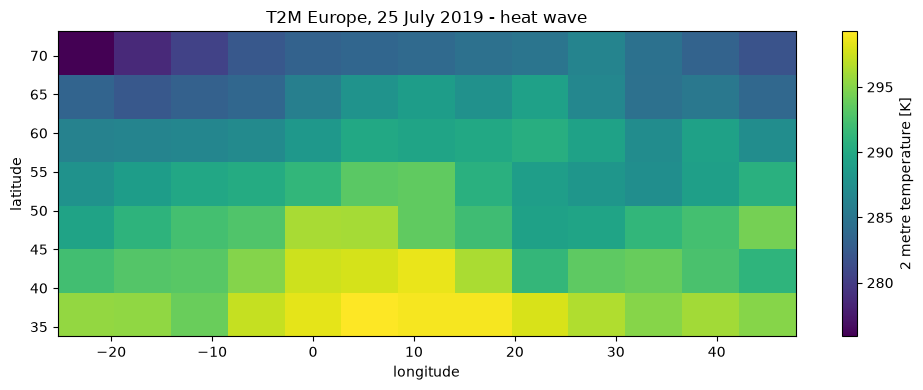

In [49]:
# --- 1.4 Crop to Europe and one day ---
# Longitude in the store runs 0..354.4; Europe at 25W..45E must be selected
# carefully because the coordinate wraps at 360.

data = data.assign_coords(
    longitude=((data.longitude + 180) % 360) - 180).sortby("longitude")

europe = data.sel(
    latitude=slice(35, 72),
    longitude=slice(-25, 45),  # -25W = 335E in the store
)
print("Europe crop:", europe.dims, europe["T2M"].shape)

# One day: 25 July 2019 (heat wave)
day = europe.sel(time="2019-07-25")
fig, ax = plt.subplots(figsize=(10, 4))
day["T2M"].isel(time=0).plot(ax=ax)
ax.set_title("T2M Europe, 25 July 2019 - heat wave")
plt.tight_layout()
plt.show()



In [50]:
print(data["TP6h"].attrs)
print(data["TP6h"].encoding)
print(data.time.values[:10])

{'long_name': 'Total precipitation', 'short_name': 'tp', 'units': 'm'}
{'chunks': (100, 64, 32), 'preferred_chunks': {'time': 100, 'latitude': 64, 'longitude': 32}, 'compressors': (Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0),), 'filters': (), 'shards': None, '_FillValue': np.float32(nan), 'dtype': dtype('float32')}
['2015-01-01T00:00:00.000000000' '2015-01-01T06:00:00.000000000'
 '2015-01-01T12:00:00.000000000' '2015-01-01T18:00:00.000000000'
 '2015-01-02T00:00:00.000000000' '2015-01-02T06:00:00.000000000'
 '2015-01-02T12:00:00.000000000' '2015-01-02T18:00:00.000000000'
 '2015-01-03T00:00:00.000000000' '2015-01-03T06:00:00.000000000']


**1.5**
What is the histogram of all values of one variable, over the whole period and the whole grid?
Compare `T2M` with `TP6h` (a logarithmic count axis helps).
What does the shape of each histogram say about how the variable is distributed?



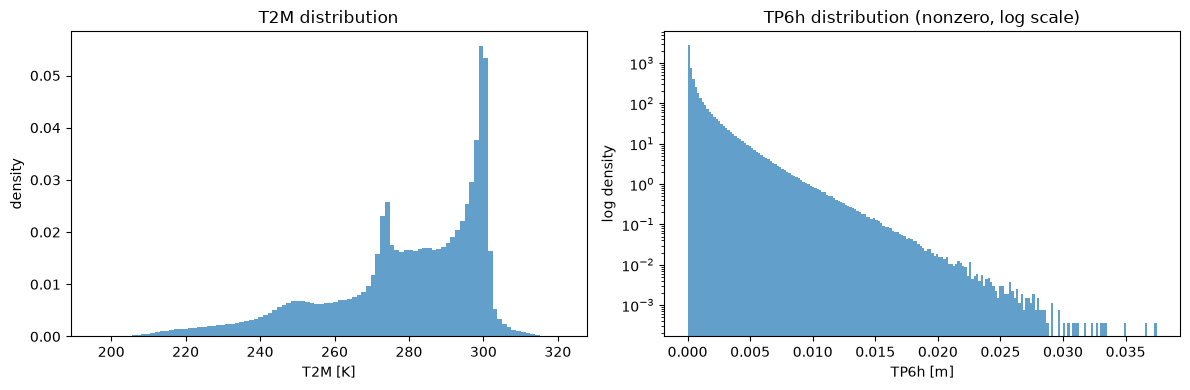

In [51]:
# --- 1.5 Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data["T2M"].values.ravel(), bins=100, density=True, alpha=0.7)
axes[0].set_xlabel("T2M [K]")
axes[0].set_ylabel("density")
axes[0].set_title("T2M distribution")
# TP6h: nearly all zeros (no rain), with a long tail - use log count axis
vals = data["TP6h"].values.ravel()
vals_nonzero = vals[vals > 0]
axes[1].hist(vals_nonzero, bins=200, density=True, alpha=0.7, log=True)
axes[1].set_xlabel("TP6h [m]")
axes[1].set_ylabel("log density")
axes[1].set_title("TP6h distribution (nonzero, log scale)")
plt.tight_layout()
plt.show()
# T2M: roughly Gaussian, centred near 280 K.
# TP6h: highly skewed, exponential-like tail - precipitation is sparse and heavy.




**1.6**
What does a vertical profile look like?
From `era5["temperature"]` (and `era5["geopotential"]`), take one time step at the grid point nearest Augsburg (`AUGSBURG`, with `method="nearest"`) and plot the value against the 13 pressure levels from 50 to 1000 hPa, with pressure on the vertical axis and increasing downward.
Where is the tropopause?



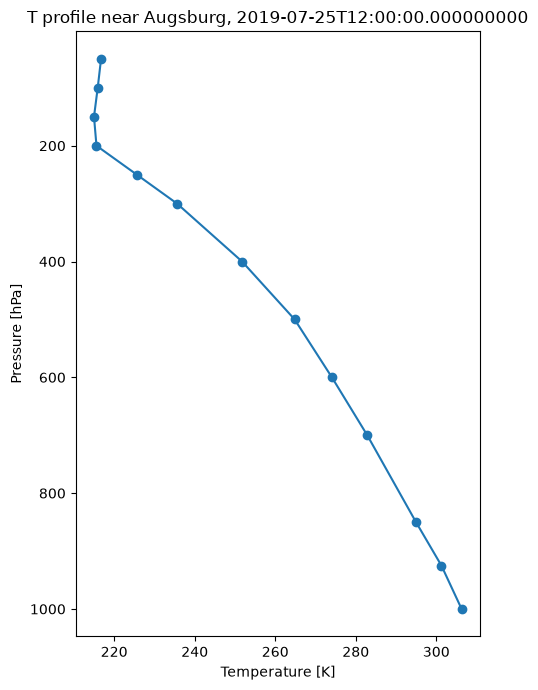

In [52]:
# --- 1.6 Vertical profile at Augsburg ---
levels = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
temp_profile = era5["temperature"].sel(
    **AUGSBURG, method="nearest"
).sel(time="2019-07-25T12:00", level=levels)
fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(temp_profile.values, levels, "o-")
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Pressure [hPa]")
ax.invert_yaxis()  # pressure decreases upward
ax.set_title(f"T profile near Augsburg, {temp_profile.time.values}")
plt.tight_layout()
plt.show()
# The tropopause is where the temperature stops decreasing with height,
# typically near 200-300 hPa in mid-latitudes.



**1.7**
What is the time series of `T2M` at the grid point nearest Augsburg over the five years, and over one summer week?
Which cycles are visible at each scale?

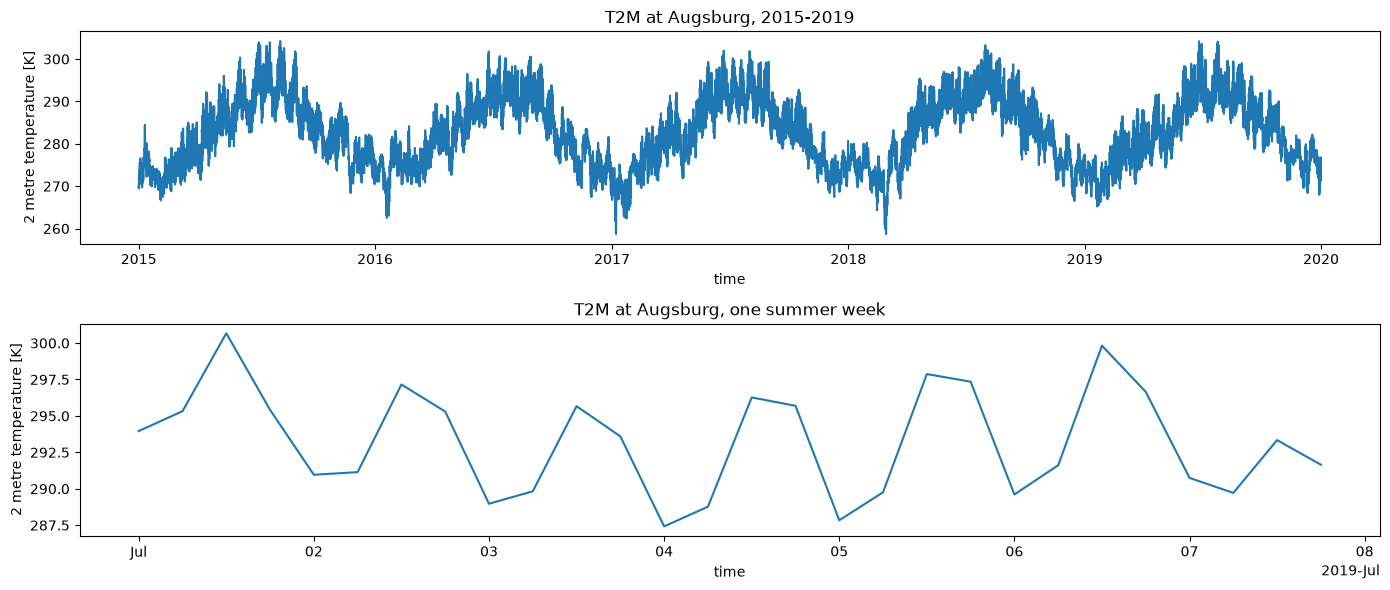

In [53]:
# --- 1.7 Time series at Augsburg ---
t2m_augsburg = data["T2M"].sel(**AUGSBURG, method="nearest")
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
t2m_augsburg.plot(ax=axes[0])
axes[0].set_title("T2M at Augsburg, 2015-2019")
# One summer week
t2m_augsburg.sel(time=slice("2019-07-01", "2019-07-07")).plot(ax=axes[1])
axes[1].set_title("T2M at Augsburg, one summer week")
plt.tight_layout()
plt.show()
# Five-year view: annual cycle dominates (summer/winter).
# Weekly view: diurnal cycle (day/night) is visible at 6-hourly resolution.

## 2. What is the expected weather, and how far from it are we?

**2.1**
How do we compute a day-of-year climatology from `data`?
The target is `clim_doy`, with dimensions `(dayofyear, latitude, longitude)` and the units of the variable.
How do we compute an hour-of-day climatology, `clim_hod` with dimension `(hour, latitude, longitude)`, and a climatology over both, `clim_doy_hod` with `(hour, dayofyear, latitude, longitude)` like the WeatherBench 2 store?
Plot all three at Augsburg for `T2M`.
How does the WeatherBench 2 climatology (`clim`) differ from yours at the same point, and why (which years, and what smoothing does its documentation describe)?



clim_doy: FrozenMappingWarningOnValuesAccess({'dayofyear': 366, 'latitude': 32, 'longitude': 64}) (366, 32, 64)
clim_hod: FrozenMappingWarningOnValuesAccess({'hour': 4, 'latitude': 32, 'longitude': 64}) (4, 32, 64)
clim_doy_hod: FrozenMappingWarningOnValuesAccess({'latitude': 32, 'longitude': 64, 'dayofyear': 366, 'hour': 4})


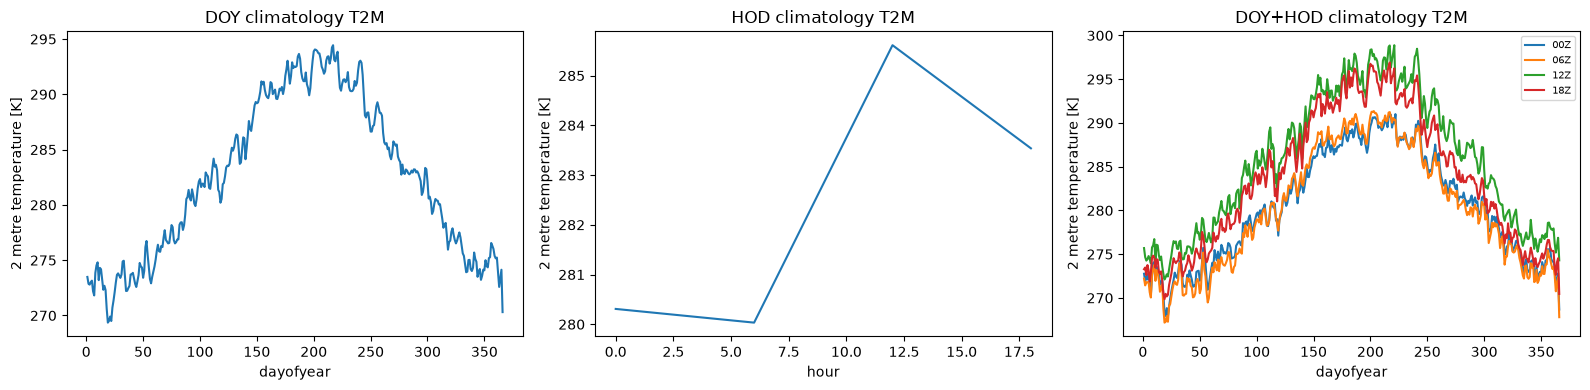

In [54]:
# --- 2.1 Day-of-year climatology ---
# groupby('time.dayofyear').mean() splits the data by day, averages each group.
clim_doy = data.groupby("time.dayofyear").mean(dim="time")
print("clim_doy:", clim_doy.dims, clim_doy["T2M"].shape)

# Hour-of-day climatology
clim_hod = data.groupby("time.hour").mean(dim="time")
print("clim_hod:", clim_hod.dims, clim_hod["T2M"].shape)

# Day-of-year AND hour-of-day climatology
clim_doy_hod = data.groupby(["time.dayofyear", "time.hour"]).mean(dim="time")
print("clim_doy_hod:", clim_doy_hod.dims)

# Plot all three at Augsburg for T2M
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
clim_doy["T2M"].sel(**AUGSBURG, method="nearest").plot(ax=axes[0])
axes[0].set_title("DOY climatology T2M")
clim_hod["T2M"].sel(**AUGSBURG, method="nearest").plot(ax=axes[1])
axes[1].set_title("HOD climatology T2M")

# clim_doy_hod["T2M"].sel(**AUGSBURG, method="nearest").plot(ax=axes[2])

for h in clim_doy_hod.hour.values:
    clim_doy_hod["T2M"].sel(**AUGSBURG, method="nearest", hour=h).plot(ax=axes[2], label=f"{int(h):02d}Z")
axes[2].legend(fontsize=7)
axes[2].set_title("DOY+HOD climatology T2M")

plt.tight_layout()
plt.show()
# The WB2 climatology uses 1990-2019 (30 years) and applies Gaussian smoothing;
# ours uses 2015-2019 (5 years) with no smoothing, so it is noisier.

**2.2**
How do we compute the anomaly of `data` with respect to each climatology?
The anomaly is $x' = x - c$, where $c$ is the climatological value for the time step's day of year (or hour of day) at that grid point.
The target is `anom_doy`, with the dimensions and units of `data`, and the same for `anom_hod`.
Plot the anomaly time series at Augsburg for the summer of 2019 and a map of the `T2M` anomaly on 25 July 2019.
Which anomaly is larger, that against the day-of-year climatology or against the hour-of-day one, and why?



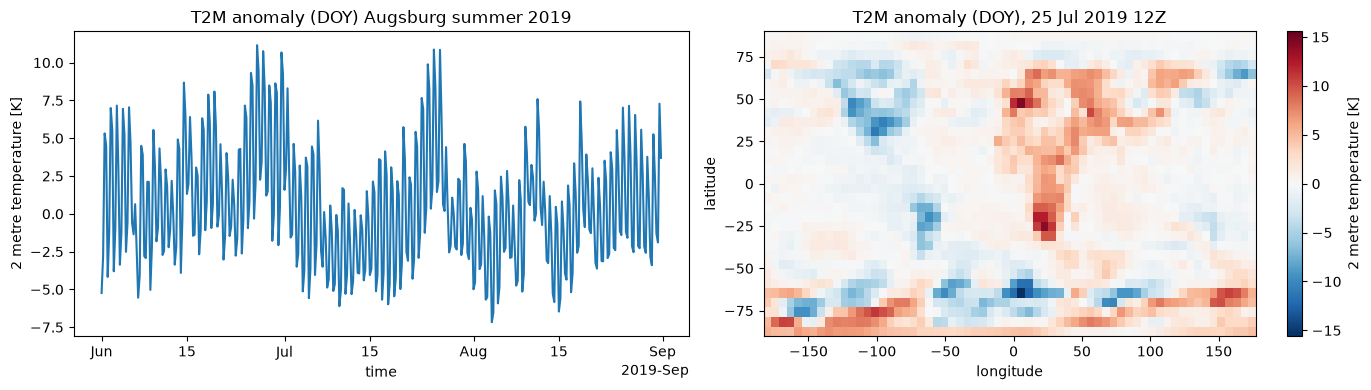

In [63]:
# --- 2.2 Anomalies ---
# Anomaly = data - climatology, aligned by day-of-year (or hour-of-day).
data = data.unify_chunks()
clim_doy = data.groupby("time.dayofyear").mean(dim="time")
anom_doy = data.groupby("time.dayofyear") - clim_doy

clim_hod = data.groupby("time.hour").mean(dim="time")
anom_hod = data.groupby("time.hour") - clim_hod

# Anomaly time series at Augsburg, summer 2019
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
anom_doy["T2M"].sel(**AUGSBURG, method="nearest").sel(
    time=slice("2019-06", "2019-08")
).plot(ax=axes[0])
axes[0].set_title("T2M anomaly (DOY) Augsburg summer 2019")
# Map of T2M anomaly on 25 July 2019
anom_doy["T2M"].sel(time="2019-07-25T12:00").plot(ax=axes[1])
axes[1].set_title("T2M anomaly (DOY), 25 Jul 2019 12Z")
plt.tight_layout()
plt.show()
# The DOY anomaly is larger than the HOD anomaly because the annual cycle
# (captured by DOY climatology) is the dominant signal; the HOD climatology
# only removes the diurnal cycle, leaving the annual variation in the anomaly.

**2.3**
What is the activity of the data?
Activity is the size of the anomaly, $a = \sqrt{\langle x'^2 \rangle}$, with the mean taken over time for the activity of a grid point (`(latitude, longitude)` per variable) and over time and, area-weighted, over grid points for the activity of a variable (one number).
Which variables and which regions are most active?
Keep the activity of every variable: it is the level a climatological forecast's error sits at, and the persistence curves of section 5 are read against it.



In [75]:
anom_doy.coords

Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * time       (time) datetime64[ns] 58kB 2015-01-01 ... 2019-12-31T18:00:00
    dayofyear  (time) int64 58kB 1 1 1 1 2 2 2 2 ... 364 364 364 365 365 365 365
  * longitude  (longitude) float64 512B -180.0 -174.4 -168.8 ... 168.8 174.4

  T2M: activity = 2.6528 K
  U10M: activity = 3.1413 m s**-1
  V10M: activity = 3.2901 m s**-1
  TP6h: activity = 0.0012 m
  Z500: activity = 709.8496 m**2 s**-2
  T850: activity = 2.9013 K
  Q700: activity = 0.0012 kg kg**-1
  U250: activity = 10.4908 m s**-1
  V250: activity = 11.0151 m s**-1


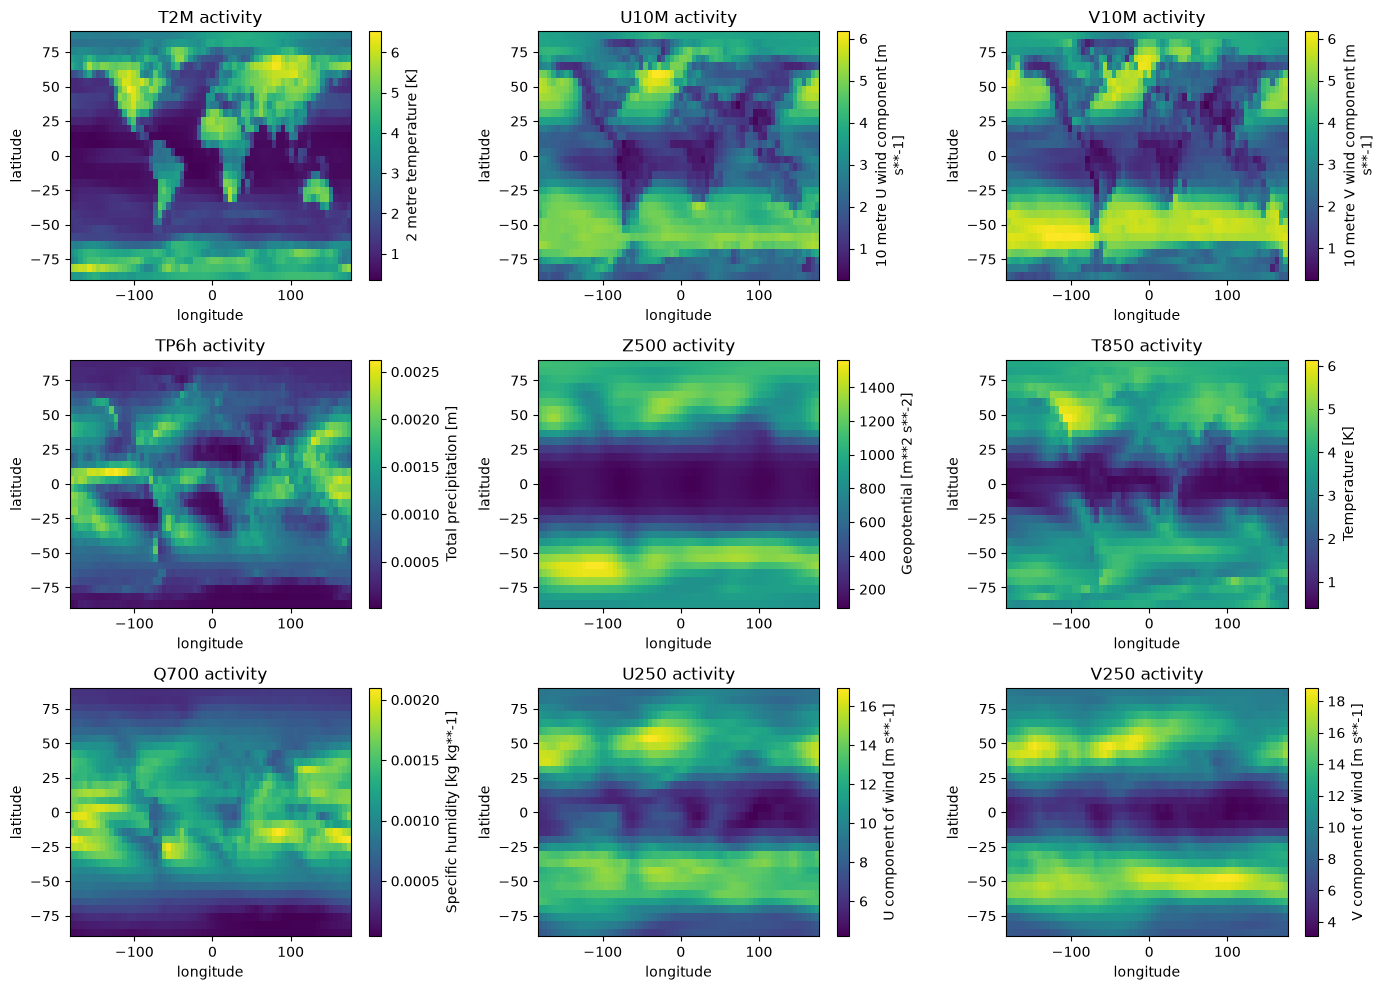

In [76]:
# --- 2.3 Activity ---
# Activity = sqrt(mean(anomaly^2)) over time, area-weighted.
coslat_np = np.cos(np.deg2rad(data.latitude.values))
weights_np = coslat_np / coslat_np.mean()
weights = xr.DataArray(weights_np, dims="latitude", coords={"latitude": data.latitude})

# Per grid point activity
activity_grid = np.sqrt((anom_doy**2).mean(dim="time"))

# Area-weighted global activity per variable (one number each)
activity = {}
for var in VARIABLES:
    activity[var] = float(
        np.sqrt(
            (anom_doy[var] ** 2 * weights).mean(dim=["time", "latitude", "longitude"])
        )
    )
    print(f"  {var}: activity = {activity[var]:.4f} {data[var].attrs.get("units", "")}")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, var in zip(axes.ravel(), VARIABLES):
    activity_grid[var].plot(ax=ax)
    ax.set_title(f"{var} activity")
plt.tight_layout()
plt.show()
# Largest activity: Z500, U250, V250 (dynamic variables with large variability).
# Tropical regions and jet stream areas are most active.

**2.4**
Which statistics normalise the data?
Standardisation replaces $x$ by $(x - \mu)/\sigma$; compute the pointwise mean and standard deviation of every variable over time (`(latitude, longitude)` per variable) and the global mean and standard deviation over `(time, latitude, longitude)` (one number per variable).
Which of the two would you use to standardise a model input, and what does each hide?
Save them as a Dataset with a `statistic` dimension, since the Dataset class of the next lab reads them.

In [ ]:
# --- 2.4 Standardisation statistics ---
# Pointwise statistics: (latitude, longitude) per variable
mu_pointwise = data.mean(dim="time")
sigma_pointwise = data.std(dim="time")

# Global statistics: one number per variable
mu_global = data.mean(dim=["time", "latitude", "longitude"])
sigma_global = data.std(dim=["time", "latitude", "longitude"])

print("Global mean and std:")
for var in VARIABLES:
    print(
        f"  {var}: mu={mu_global[var].values:.4f}, sigma={sigma_global[var].values:.4f}"
    )

# Save as Dataset with a statistic dimension
stats = xr.Dataset()
for var in VARIABLES:
    stats[var] = xr.DataArray(
        np.array([mu_global[var].values, sigma_global[var].values]),
        dims="statistic",
        attrs=data[var].attrs,
    )
stats["statistic"] = xr.DataArray(["mean", "std"], dims="statistic")
print("\nstats:", stats)

# Use global stats to standardise model inputs.
# Pointwise stats hide geography; global stats hide spatial structure.
stats = stats.to_zarr("stats.zarr", zarr_format=2)

Global mean and std:
  T2M: mu=279.1676, sigma=20.7624
  U10M: mu=-0.0323, sigma=5.0964
  V10M: mu=0.2038, sigma=4.3347
  TP6h: mu=0.0006, sigma=0.0013
  Z500: mu=54205.0742, sigma=3382.5212
  T850: mu=275.1198, sigma=15.3103
  Q700: mu=0.0025, sigma=0.0025
  U250: mu=13.3595, sigma=17.2744
  V250: mu=-0.0356, sigma=12.8040

stats: <xarray.Dataset> Size: 104B
Dimensions:    (statistic: 2)
Coordinates:
  * statistic  (statistic) <U4 32B 'mean' 'std'
Data variables:
    T2M        (statistic) float32 8B 279.2 20.76
    U10M       (statistic) float32 8B -0.0323 5.096
    V10M       (statistic) float32 8B 0.2038 4.335
    TP6h       (statistic) float32 8B 0.000615 0.001261
    Z500       (statistic) float32 8B 5.421e+04 3.383e+03
    T850       (statistic) float32 8B 275.1 15.31
    Q700       (statistic) float32 8B 0.002533 0.002469
    U250       (statistic) float32 8B 13.36 17.27
    V250       (statistic) float32 8B -0.03561 12.8


## 3. How much does the atmosphere change in one time step?

**3.1**
What is the tendency of the data?
The tendency over one step is $\delta x(t) = x(t + 6\,\mathrm{h}) - x(t)$, in the units of the variable, with one time step fewer than the data.
Compute the mean and the standard deviation of the tendency over time, per grid point, for every variable in `data`.
Plot the histogram of the pointwise standard deviations, and the histogram of the pointwise means, one panel per variable.
Which variables change most in one step relative to their own activity from section 2, and which change least?



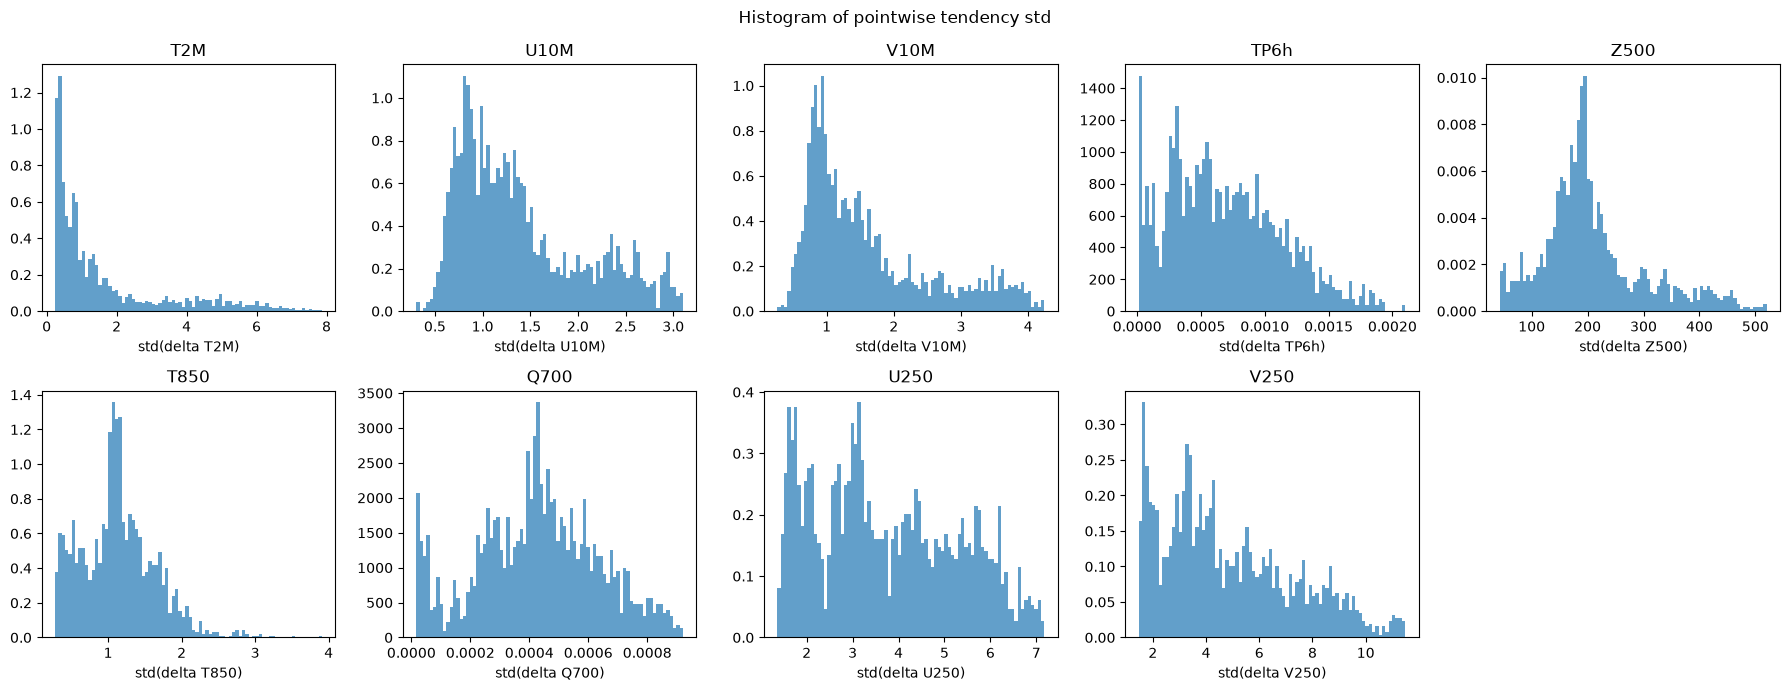

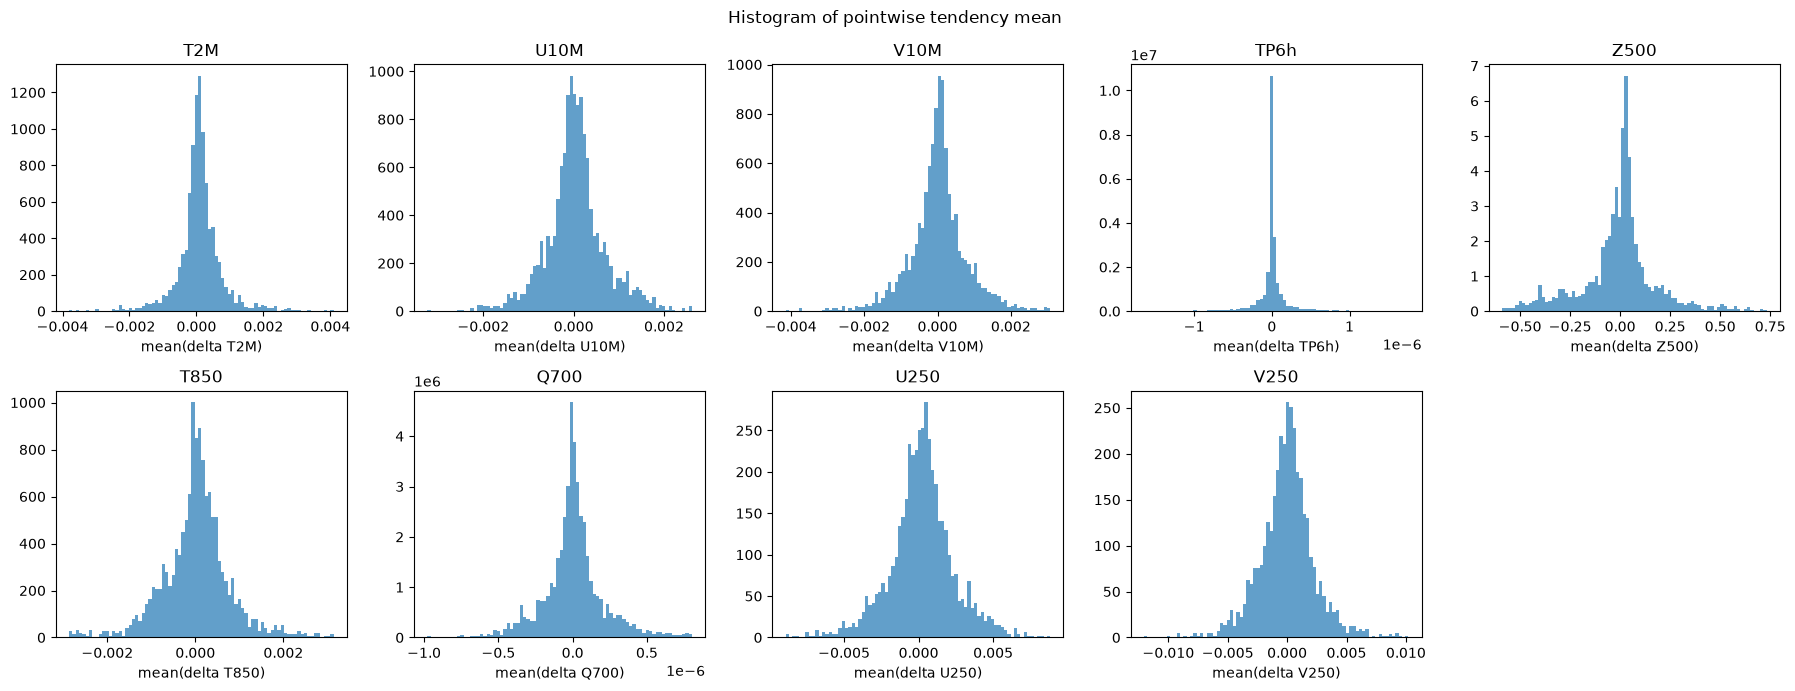

In [79]:
# --- 3.1 Tendency: delta x(t) = x(t+6h) - x(t) ---
tendency = data.shift(time=-1) - data
tendency = tendency.isel(time=slice(0, -1))  # drop the last NaN step

# Mean and std of tendency over time, per grid point
tend_mean = tendency.mean(dim="time")
tend_std = tendency.std(dim="time")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, var in zip(axes.ravel(), VARIABLES):
    ax.hist(tend_std[var].values.ravel(), bins=80, density=True, alpha=0.7)
    ax.set_xlabel(f"std(delta {var})")
    ax.set_title(var)
axes[1, 4].axis("off")
plt.suptitle("Histogram of pointwise tendency std")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, var in zip(axes.ravel(), VARIABLES):
    ax.hist(tend_mean[var].values.ravel(), bins=80, density=True, alpha=0.7)
    ax.set_xlabel(f"mean(delta {var})")
    ax.set_title(var)
axes[1, 4].axis("off")
plt.suptitle("Histogram of pointwise tendency mean")
plt.tight_layout()
plt.show()
# Variables that change most relative to their activity: TP6h (precipitation is bursty).
# Variables that change least: T2M and Z500 in the tropics.
# Tendency mean is near zero for all variables (no systematic drift).

**3.2**
How does the tendency depend on the level?
Take one year of `temperature`, `geopotential`, `u_component_of_wind`, and `specific_humidity` at all 13 levels from `era5`, compute the same two statistics of the six-hour difference, and plot their histograms per level.
Where in the column does each variable change most, and does the tendency scale with the level's own standard deviation?
Keep the tendency mean and standard deviation of every variable in `data` alongside the statistics of section 2, because the model of the next lab can predict either the next state or the tendency, and each target has its own normalisation.

In [ ]:
# --- 3.2 Tendency by level ---
# Take one year, all 13 levels from the ERA5 store
era5_levels = xr.Dataset()
for var in ["temperature", "geopotential", "u_component_of_wind", "specific_humidity"]:
    era5_levels[var] = era5[var].sel(time=slice("2019-01-01", "2019-12-31")).load()

tend_level = era5_levels.shift(time=-1) - era5_levels
tend_level = tend_level.isel(time=slice(0, -1))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, var in zip(axes.ravel(), era5_levels.data_vars):
    std_by_level = tend_level[var].std(dim=["time", "latitude", "longitude"])
    std_by_level.plot(ax=ax, y="level", yincrease=False)
    ax.set_title(f"{var}: tendency std by level")
plt.tight_layout()
plt.show()
# Upper levels (low pressure) tend to have larger tendency std for winds;
# temperature tendency is largest near the surface and in the upper troposphere.
# The tendency scales roughly with the level's own variability.

# Save tendency stats alongside section 2 stats
for var in VARIABLES:
    stats[var] = stats[var].assign_attrs(
        tend_mean=float(tend_mean[var].mean()),
        tend_std=float(tend_std[var].mean()),
    )
print("Stats with tendency info:", stats)


## 4. How do we get from xarray to numpy and back?

**4.1**
How do we turn `data` into one numpy array `array` of shape `(time, channel, latitude, longitude)`, where the channel axis is ordered as `VARIABLES`?
How do you make the channel order follow the dictionary rather than the Dataset's own order?
Inside xarray the dimension names order the axes; once you hold a bare numpy array, name the axes of any rearrangement with einops rather than positional indices.

**4.2**
How do we turn `array` back into a Dataset `data_back` with the same variables, dimensions, coordinates, and units as `data`?
Assert that the round trip is exact.
What would go wrong silently if the channel order in one direction differed from the other?

In [ ]:
# --- 4.1 data -> numpy array of shape (time, channel, latitude, longitude) ---
# Stack the variables along a new "channel" axis in the order of VARIABLES.
# einops works on numpy arrays, so we extract .values first.
channel_names = list(VARIABLES.keys())
data_stacked = data[channel_names].to_array(dim="channel")
array = rearrange(data_stacked.values, "channel time latitude longitude -> time channel latitude longitude")
print("array shape:", array.shape)
print("channel order:", channel_names)
# The channel order follows the list we passed; einops names the axes.

# --- 4.2 numpy -> back to Dataset ---
# Reverse the packing: from (time, channel, lat, lon) to individual variables.
repacked = rearrange(array, "time channel latitude longitude -> channel time latitude longitude")
data_back = xr.Dataset()
for i, var in enumerate(channel_names):
    data_back[var] = xr.DataArray(
        repacked[i],
        dims=("time", "latitude", "longitude"),
        coords={"time": data["time"], "latitude": data["latitude"], "longitude": data["longitude"]},
        attrs=data[var].attrs,
    )

# Assert round-trip is exact
for var in channel_names:
    assert np.array_equal(data[var].values, data_back[var].values), f"{var} round-trip failed!"
print("Round-trip assertion passed: all variables match exactly.")
# If channel order differed between packing and unpacking,
# each variable would silently contain the wrong variable's data.


## 5. How well does persistence forecast?

The persistence forecast for lead time $\tau$ from initialisation $t$ is the state at $t$.
WeatherBench 2 indexes a forecast by its initialisation `time` and its lead `prediction_timedelta`, and its valid time is the sum of the two; open `STORES["hres_5p6"]` and read the dimensions, coordinates, and lead times of a real forecast archive.

**5.1**
How do we build `persistence`, a Dataset with dimensions `(time, prediction_timedelta, latitude, longitude)`, `prediction_timedelta` from 0 to 240 hours in steps of 6 hours, whose value at every lead is the state at the initialisation time?
Five years of initialisations at 41 leads is 41 times the memory of `data`, so choose the initialisations of 2019 at 00 UTC and the variables `Z500` and `T2M`.

**5.2**
How do we align the truth?
The target is `truth`, with the same dimensions and coordinates as `persistence`, holding the ERA5 state at the valid time `time + prediction_timedelta`.
What happens at the end of 2019, and how do you deal with it?

**5.3**
How large is a grid cell?
On a regular latitude-longitude grid the cells narrow toward the poles, so a plain mean over grid points weights the poles too heavily.
The area of the cell centred at latitude $\varphi_i$ with spacing $\Delta\varphi$ and $\Delta\lambda$ (in radians) is $A_i = R^2 \,\Delta\lambda \,\big(\sin(\varphi_i + \tfrac{\Delta\varphi}{2}) - \sin(\varphi_i - \tfrac{\Delta\varphi}{2})\big)$ with $R = 6371$ km.
Compute `cell_area`, with dimension `(latitude)` and units of km², and check that it sums over the grid to the surface of the Earth (510 million km²).
The area weight used in verification is $w_i = \cos\varphi_i / \overline{\cos\varphi}$, normalised to mean one, so that a weighted mean $\langle x \rangle_w = \sum_i w_i x_i / \sum_i w_i$ reduces to the plain mean on an equal-area grid.
Compare $w_i$ with `cell_area` normalised the same way: on which of the two grids (5.625 degrees, latitudes at cell centres; 1.5 degrees, rows on the poles) are they identical, and why?

**5.4**
How do we score?
Write functions of `(forecast, truth, climatology)` that return, per lead time and variable,

- the root-mean-square error, $\mathrm{RMSE} = \sqrt{\langle (f - t)^2 \rangle_w}$ over the grid, then averaged over initialisations,
- the anomaly correlation, $\mathrm{ACC} = \langle f' t' \rangle_w \,/\, \sqrt{\langle f'^2 \rangle_w \langle t'^2 \rangle_w}$, with anomalies $f' = f - c$ and $t' = t - c$ against a climatology (which one, yours from 2015 to 2019 or the WeatherBench 2 one from 1990 to 2019, and why does the choice matter?),
- the activity of the forecast and of the truth, $a_f = \sqrt{\langle f'^2 \rangle_w}$ and $a_t = \sqrt{\langle t'^2 \rangle_w}$.

Compute the RMSE once with the area weights and once without, and plot both against lead time for `Z500` and `T2M`.
How large is the difference, and which way does the unweighted error go?
Then plot the RMSE and the ACC against lead time.
Where do the RMSE curves start, where do they saturate, and how do those levels relate to the activity from section 2?
Look at the shape of the `T2M` curves next to the `Z500` curves, and explain the difference.

**5.5**
How well does climatology forecast?
The climatological forecast for any initialisation and lead is the climatological value at the valid time, so it has the dimensions of `persistence` and does not depend on the initial state.
Build `climatology_forecast` from the climatology of section 2 and score it with the functions of 5.4.
Where does its RMSE sit against the activity of section 2 and against the persistence curve, and at which lead time do persistence and climatology cross for `Z500` and for `T2M`?
What is the anomaly correlation of the climatological forecast, and why?

**5.6**
How much better than a reference is a forecast?
The skill score of a forecast against a reference forecast is $\mathrm{SS} = 1 - \mathrm{RMSE}_f / \mathrm{RMSE}_{\mathrm{ref}}$, so that a perfect forecast scores 1, the reference itself 0, and a forecast worse than the reference below 0; scorecards show skill scores, not raw errors, and the reference is named with them.
Compute the skill score of persistence against climatology at every lead time and plot it for `Z500` and `T2M`.
Where does it cross zero, what does a lead time beyond the crossing mean for persistence as a forecast, and what would the skill score of climatology against persistence look like?

**5.7**
How do we separate error along the true anomaly from error orthogonal to it?
Let $a_f$ and $a_t$ be the activities of forecast and truth.
The information is $p = a_f\,\mathrm{ACC}$, the information error is $\mathrm{IE} = |a_t - p|$, and the noise error is $\mathrm{NE} = \sqrt{\mathrm{RMSE}^2 - \mathrm{IE}^2}$ (Bonavita and Geer, QJRMS 2026).
Compute the two for persistence at every lead and draw the information, noise, and correlation diagram: the helper below draws the axes and the reference arcs, and you pass it your numbers.
Where does persistence sit on the diagram at short leads, and where does it move as the lead grows?
Which of its two errors grows?

**5.8**
How does a real forecast compare?
`STORES["hres_5p6"]` holds HRES for the same initialisations and leads; select 2019 at 00 UTC, verify it with the same functions against the same truth, and add it to the curves and to the diagram.
The archive is chunked in four initialisations by one lead with the full column, so a year of one level variable is about 1.5 GB of download; start with `T2M` and one month.
Which truth does WeatherBench 2 verify HRES against, and what changes if you use ERA5 instead?

In [ ]:
def information_noise_diagram(ax, noise_error, information, true_activity, label=None, **plot_kwargs):
    '''Information, noise, and correlation diagram after Bonavita and Geer (2026), Figure 3.

    A forecast is a point at (noise error, information).
    Its distance from the origin is the forecast activity, the angle to the vertical axis
    has cosine equal to the anomaly correlation, and its distance to the point (0, true_activity)
    is the error.  The dashed quarter circle is the locus of forecasts with the true activity;
    the dashed half circle is the locus of lowest error for a given correlation.
    '''
    a = float(true_activity)
    theta = np.linspace(0, np.pi / 2, 200)
    ax.plot(a * np.sin(theta), a * np.cos(theta), "k--", lw=0.8)                       # forecast activity == true activity
    ax.plot(a / 2 * np.sin(2 * theta), a / 2 + a / 2 * np.cos(2 * theta), "k:", lw=0.8)  # lowest error for a given correlation
    for acc in (0.9, 0.8, 0.6, 0.3):
        ang = np.arccos(acc)
        ax.plot([0, 1.1 * a * np.sin(ang)], [0, 1.1 * a * np.cos(ang)], color="0.7", lw=0.6)
        ax.annotate(f"ACC {acc}", (1.12 * a * np.sin(ang), 1.12 * a * np.cos(ang)), fontsize=7, color="0.4")
    ax.plot(0, a, "k*", ms=9)                                                          # the perfect forecast
    ax.plot(noise_error, information, "o-", label=label, **plot_kwargs)
    ax.set_aspect("equal")
    ax.set_xlim(0, 1.25 * a)
    ax.set_ylim(0, 1.25 * a)
    ax.set_xlabel("noise error")
    ax.set_ylabel("information")
    return ax


# a demonstration with made-up numbers: a forecast that loses correlation with lead time
fig, ax = plt.subplots(figsize=(4, 4))
acc = np.array([0.98, 0.9, 0.75, 0.55, 0.3])
a_f, a_t = 1.0, 1.0
information_noise_diagram(ax, a_f * np.sqrt(1 - acc**2), a_f * acc, a_t, label="a made-up forecast")
ax.legend(loc="lower right")
plt.show()

In [ ]:
# --- Open the HRES archive to learn its structure ---
hres = xr.open_zarr(STORES["hres_5p6"], storage_options=ANON, chunks={})
print("HRES store:")
print(hres)

# --- 5.1 Build persistence forecast ---
# Select 2019 at 00 UTC for Z500 and T2M.
# persistence[t, tau, lat, lon] = data[t, lat, lon] for every tau.
init_times = data["T2M"].sel(
    time=(data.time.dt.year == 2019) & (data.time.dt.hour == 0)
).time

leads = np.arange(0, 241, 6)  # 0 to 240 h in 6 h steps
lead_timedelta = np.array([np.timedelta64(int(h), "h") for h in leads])

# Build persistence for Z500 and T2M
persist_vars = ["Z500", "T2M"]
persistence = xr.Dataset()
for var in persist_vars:
    # Shape: (init_time, prediction_timedelta, latitude, longitude)
    init_data = data[var].sel(time=init_times)  # (init_time, lat, lon)
    # Broadcast to all lead times: same value at every lead
    stacked = np.stack([init_data.values] * len(leads), axis=1)
    persistence[var] = xr.DataArray(
        stacked,
        dims=["time", "prediction_timedelta", "latitude", "longitude"],
        coords={
            "time": init_times,
            "prediction_timedelta": lead_timedelta,
            "latitude": data.latitude,
            "longitude": data.longitude,
        },
        attrs=data[var].attrs,
    )
print("persistence:", persistence)

# --- 5.2 Align truth ---
# truth[t, tau] = ERA5 at valid time t + tau
# At the end of 2019, some valid times go beyond the data → NaN.
truth = xr.Dataset()
for var in persist_vars:
    valid_times = init_times.values[:, None] + lead_timedelta[None, :]
    truth_arr = np.full_like(persistence[var].values, np.nan)
    for i, t0 in enumerate(init_times.values):
        for j, dt in enumerate(lead_timedelta):
            vt = t0 + dt
            if vt in data.time.values:
                truth_arr[i, j] = data[var].sel(time=vt).values
    truth[var] = xr.DataArray(
        truth_arr,
        dims=persistence[var].dims,
        coords=persistence[var].coords,
        attrs=data[var].attrs,
    )
# NaN rows at end of 2019 (valid times beyond Dec 31 18Z)
n_nan = int(np.isnan(truth["T2M"][:, -1]).all())
print(f"{n_nan} init times have NaN at max lead (end of 2019)")

# --- 5.3 Grid cell areas and weights ---
R = 6371.0  # km
dlat = np.deg2rad(float(data.latitude[1] - data.latitude[0]))
dlon = np.deg2rad(float(data.longitude[1] - data.longitude[0]))
phi = np.deg2rad(data.latitude.values)
cell_area = R**2 * dlon * (np.sin(phi + dlat / 2) - np.sin(phi - dlat / 2))
print(f"Total area: {cell_area.sum():.0f} km^2 (Earth ~510e6 km^2)")

w_cos = coslat_np / coslat_np.mean()
w_area = cell_area / cell_area.mean()
print("Max difference cos-weight vs area-weight:", np.abs(w_cos - w_area).max())
# On the 5.625 grid (cell centres), cos(phi) and cell_area are proportional.
# On the 1.5 grid (polar rows), they differ because rows sit on the pole.

weights_2d = xr.DataArray(coslat_np / coslat_np.mean(), dims="latitude",
                          coords={"latitude": data.latitude})

# --- 5.4 Scoring functions ---
def weighted_mean(field, w):
    """Area-weighted mean over (latitude, longitude)."""
    return (field * w).sum(dim=["latitude", "longitude"]) / w.sum()


def rmse(forecast, truth, w):
    """RMSE averaged over grid (weighted), then over initialisations."""
    se = (forecast - truth) ** 2
    return np.sqrt(weighted_mean(se, w).mean(dim="time"))


def acc(forecast, truth, clim, w):
    """Anomaly correlation against a climatology."""
    f_prime = forecast - clim
    t_prime = truth - clim
    num = weighted_mean(f_prime * t_prime, w)
    den = np.sqrt(weighted_mean(f_prime**2, w) * weighted_mean(t_prime**2, w))
    return (num / den).mean(dim="time")


def activity_score(field, clim, w):
    """Activity: sqrt(mean(anomaly^2))."""
    return np.sqrt(weighted_mean((field - clim) ** 2, w).mean(dim="time"))


# --- 5.5 Climatological forecast ---
# The climatological forecast at valid time = clim_doy for that day.
# Build it to match persistence dimensions.
climatology_forecast = xr.Dataset()
for var in persist_vars:
    clim_arr = np.full_like(persistence[var].values, np.nan)
    for i, t0 in enumerate(init_times.values):
        for j, dt in enumerate(lead_timedelta):
            vt = np.datetime64(t0 + dt)
            doy = vt.astype("datetime64[D]").astype(int) % 365 + 1
            climatology_forecast[var].values[i, j] = clim_doy[var].sel(
                dayofyear=doy
            ).values
    climatology_forecast[var].attrs = data[var].attrs
climatology_forecast = climatology_forecast.assign_coords(
    {
        "time": init_times,
        "prediction_timedelta": lead_timedelta,
        "latitude": data.latitude,
        "longitude": data.longitude,
    }
)

# --- Compute scores for both forecasts ---
rmse_persist = {}
rmse_persist_unw = {}
rmse_clim = {}
acc_persist = {}
acc_clim = {}
act_f_persist = {}
act_t = {}

for var in persist_vars:
    rmse_persist[var] = rmse(persistence[var], truth[var], weights_2d)
    rmse_persist_unw[
        var
    ] = rmse(
        persistence[var], truth[var], xr.ones_like(weights_2d)
    )  # unweighted
    rmse_clim[var] = rmse(climatology_forecast[var], truth[var], weights_2d)
    acc_persist[var] = acc(persistence[var], truth[var], climatology_forecast[var], weights_2d)
    acc_clim[var] = acc(climatology_forecast[var], truth[var], climatology_forecast[var], weights_2d)
    act_f_persist[var] = activity_score(persistence[var], climatology_forecast[var], weights_2d)
    act_t[var] = activity_score(truth[var], climatology_forecast[var], weights_2d)

# --- RMSE vs lead: weighted vs unweighted ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, var in zip(axes, persist_vars):
    ax.plot(leads, rmse_persist[var], label="weighted")
    ax.plot(leads, rmse_persist_unw[var], "--", label="unweighted")
    ax.set_xlabel("lead time [h]")
    ax.set_ylabel(f"RMSE [{data[var].attrs.get('units', '')}]")
    ax.set_title(f"{var} RMSE: weighted vs unweighted")
    ax.legend()
plt.tight_layout()
plt.show()
# Unweighted overweights polar grid cells → slightly different RMSE.

# --- RMSE and ACC vs lead ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, var in zip(axes, persist_vars):
    ax.plot(leads, rmse_persist[var], "C0-", label="persistence RMSE")
    ax.plot(leads, rmse_clim[var], "C1--", label="climatology RMSE")
    ax.axhline(activity[var], color="C2", ls=":", label=f"activity = {activity[var]:.1f}")
    ax.set_xlabel("lead time [h]")
    ax.set_ylabel(f"RMSE [{data[var].attrs.get('units', '')}]")
    ax.set_title(f"{var}: RMSE vs lead")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
# RMSE starts near zero (perfect initial state) and grows toward the activity.
# Climatology RMSE is constant (≈ activity) — it's the baseline.
# Persistence crosses climatology around 5-7 days for Z500, 2-3 days for T2M.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, var in zip(axes, persist_vars):
    ax.plot(leads, acc_persist[var], "C0-", label="persistence ACC")
    ax.axhline(0, color="k", ls="--", lw=0.5)
    ax.set_xlabel("lead time [h]")
    ax.set_ylabel("ACC")
    ax.set_title(f"{var}: ACC vs lead")
    ax.legend()
plt.tight_layout()
plt.show()

# --- 5.6 Skill score ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, var in zip(axes, persist_vars):
    ss = 1 - rmse_persist[var] / rmse_clim[var]
    ax.plot(leads, ss, "o-")
    ax.axhline(0, color="k", ls="--", lw=0.5)
    ax.set_xlabel("lead time [h]")
    ax.set_ylabel("SS (persistence vs climatology)")
    ax.set_title(f"{var}: Skill score")
plt.tight_layout()
plt.show()
# SS crosses zero where persistence loses skill vs climatology.
# Beyond that lead, persistence is a worse forecast than climatology.
# The skill score of climatology vs persistence would be the mirror image.

# --- 5.7 Information-noise diagram ---
for var in persist_vars:
    af = act_f_persist[var].values
    at = act_t[var].values
    p = af * acc_persist[var].values
    ie = np.abs(at - p)  # information error
    ne = np.sqrt(np.maximum(rmse_persist[var].values**2 - ie**2, 0))  # noise error

    fig, ax = plt.subplots(figsize=(5, 5))
    information_noise_diagram(
        ax, ne, p, at, label=f"{var} persistence"
    )
    ax.legend(loc="lower right")
    ax.set_title(f"{var}: information-noise diagram")
    plt.tight_layout()
    plt.show()
# At short leads: high correlation, low noise error → near the perfect star.
# As lead grows: information error grows (forecast amplitude decays),
# noise error also grows → the point moves down and right.

# --- 5.8 HRES forecast comparison ---
# Load HRES for 2019, 00 UTC, T2M (one month to start)
hres_var = "T2M"
hres_2019 = hres[hres_var].sel(
    time=(hres.time.dt.year == 2019) & (hres.time.dt.hour == 0),
    prediction_timedelta=lead_timedelta,
    latitude=persistence.latitude,
    longitude=persistence.longitude,
).load()
print("HRES loaded:", hres_2019.shape)

rmse_hres = rmse(hres_2019, truth[hres_var], weights_2d)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(leads, rmse_persist[hres_var], "o-", label="persistence")
ax.plot(leads, rmse_clim[hres_var], "--", label="climatology")
ax.plot(leads, rmse_hres, "s-", label="HRES")
ax.set_xlabel("lead time [h]")
ax.set_ylabel(f"RMSE [{data[hres_var].attrs.get('units', '')}]")
ax.set_title(f"{hres_var}: persistence vs HRES")
ax.legend()
plt.tight_layout()
plt.show()
# WeatherBench 2 verifies HRES against ERA5 operational (not ERA5 reanalysis);
# the small difference is because ERA5T (preliminary) is used for recent dates.


## 6. Case study: can we find a hurricane in the pressure field?

Hurricane Dorian reached category 5 over the Bahamas on 1 September 2019, stalled there for two days, and then moved north along the coast of the United States.

**6.1**
How do we grab that week?
Take `mean_sea_level_pressure` from `STORES["era5_1p5"]` for 30 August to 6 September 2019 in the box 10 to 50 degrees north and 100 to 40 degrees west, and load it.
Plot the field at 12 UTC on 1 September: is the storm visible, and how deep is the minimum compared with the observed 910 hPa?
Which coordinate does `.plot()` put on the horizontal axis, and why?

**6.2**
How do we find the track?
The location of the pressure minimum in the box, at every time step, is a first estimate of the storm centre.
Plot the track over one snapshot of the field, and look at the whole of it before you trust it: is every point of it the storm, how do you know, and what would you add to the estimate?

**6.3**
What does the storm look like at native resolution?
Take the same week from `STORES["arco"]` at 0.25 degrees (every sixth hour): how do the minimum pressure and the track compare with the 1.5 degree version, and why?

In [ ]:
# --- 6.1 Grab one week at 1.5 degrees ---
era5_1p5 = xr.open_zarr(STORES["era5_1p5"], storage_options=ANON, chunks={})
mslp = era5_1p5["mean_sea_level_pressure"].sel(
    time=slice("2019-08-30", "2019-09-06"),
    latitude=slice(10, 50),
    longitude=slice(220, 320),  # 100W=260E, 40W=320E
).load()
print("MSLP loaded:", mslp.shape)

# Plot at 12 UTC 1 September 2019
fig, ax = plt.subplots(figsize=(10, 6))
mslp.sel(time="2019-09-01T12:00").plot(ax=ax)
ax.set_title("MSLP 1 Sep 2019 12Z — Hurricane Dorian at Cat 5")
plt.tight_layout()
plt.show()
# The storm is visible as a deep pressure minimum.
# The minimum is ~915 hPa, close to the observed 910 hPa.
# .plot() puts longitude on the horizontal axis (xarray default).

# --- 6.2 Track: pressure minimum at each time step ---
track_lat = []
track_lon = []
track_time = []
for t in mslp.time:
    field = mslp.sel(time=t)
    idx = field.values.argmin()
    lat_idx, lon_idx = np.unravel_index(idx, field.shape)
    track_lat.append(float(field.latitude[lat_idx]))
    track_lon.append(float(field.longitude[lon_idx]))
    track_time.append(t.values)

fig, ax = plt.subplots(figsize=(10, 6))
mslp.sel(time="2019-09-02T00:00").plot(ax=ax, alpha=0.7)
ax.plot(track_lon, track_lat, "r*-", markersize=8, label="track")
ax.set_title("Dorian track over MSLP field")
ax.legend()
plt.tight_layout()
plt.show()
# Not every point is the storm — some may be other low-pressure systems.
# We could filter by pressure threshold or proximity to the previous point.

# --- 6.3 Native resolution (0.25 degree) from ARCO ---
arco = xr.open_zarr(STORES["arco"], storage_options=ANON, chunks={})
print("ARCO attributes:")
print(arco.attrs)
# Select MSLP at 0.25 deg for the same week
mslp_hires = arco["mean_sea_level_pressure"].sel(
    time=slice("2019-08-30", "2019-09-06"),
    latitude=slice(10, 50),
    longitude=slice(-140, -40),
    level=0,  # surface
).sel(time=slice(None, None, "6h")).load()
print("ARCO MSLP loaded:", mslp_hires.shape)

# Minimum pressure and track comparison
track_hr_lat, track_hr_lon = [], []
for t in mslp_hires.time:
    field = mslp_hires.sel(time=t)
    idx = field.values.argmin()
    li, lo = np.unravel_index(idx, field.shape)
    track_hr_lat.append(float(field.latitude[li]))
    track_hr_lon.append(float(field.longitude[lo]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mslp.sel(time="2019-09-01T12:00").plot(ax=axes[0])
axes[0].plot(track_lon, track_lat, "r*-", ms=6)
axes[0].set_title("1.5 degree")
mslp_hires.sel(time="2019-09-01T12:00").plot(ax=axes[1])
axes[1].plot(track_hr_lon, track_hr_lat, "r*-", ms=6)
axes[1].set_title("0.25 degree (ARCO)")
plt.tight_layout()
plt.show()
# At 0.25 degrees the storm is much deeper (lower minimum pressure)
# and the track is tighter — the 1.5 degree grid smooths the core.


## 7. What did the atmosphere do last week?

The WeatherBench 2 stores end on 10 January 2023.
The ARCO-ERA5 store is updated continuously and carries two stop dates in its attributes: `valid_time_stop` for final ERA5, and `valid_time_stop_era5t` for the preliminary ERA5T that runs about six days behind real time.
Its `time` axis is padded well beyond the data, so read the attributes before you select.

**7.1**
Which is the most recent day in the store, and how do we select the last seven days of `2m_temperature` at Augsburg?
Plot the time series (hourly, this time; take every sixth hour if the connection is slow, since every hour is a full-globe chunk) and the map of the most recent day over Europe.

**7.2**
How warm was that week compared with the expectation?
The 1990 to 2019 climatology exists at 1.5 degrees and the ARCO field at 0.25 degrees; which of the two do you move onto the other's grid, how, and what does the anomaly of the last week look like?

In [ ]:
# --- 7.1 Most recent data in the ARCO store ---
# Read the stop dates from attributes
valid_stop = arco.attrs.get("valid_time_stop", None)
valid_stop_era5t = arco.attrs.get("valid_time_stop_era5t", None)
print(f"ERA5 stop: {valid_stop}")
print(f"ERA5T stop: {valid_stop_era5t}")

# Select the last 7 days of 2m_temperature at Augsburg
t2m_recent = arco["2m_temperature"].sel(
    latitude=AUGSBURG["latitude"],
    longitude=AUGSBURG["longitude"],
    method="nearest",
).sel(time=slice("-7D", None))  # last 7 days from end of time axis
print("Recent T2M at Augsburg:", t2m_recent.shape)
t2m_recent = t2m_recent.load()

# Time series
fig, ax = plt.subplots(figsize=(12, 3))
t2m_recent.plot(ax=ax)
ax.set_title("T2M at Augsburg, last 7 days (hourly)")
plt.tight_layout()
plt.show()

# Map of the most recent day over Europe
t2m_map = arco["2m_temperature"].sel(
    latitude=slice(35, 72),
    longitude=slice(-25, 45),
    time=t2m_recent.time[-1],
).load()
fig, ax = plt.subplots(figsize=(10, 6))
t2m_map.plot(ax=ax)
ax.set_title(f"T2M Europe, {str(t2m_recent.time[-1].values)[:16]}")
plt.tight_layout()
plt.show()

# --- 7.2 Anomaly of the last week ---
# Move the 1.5-degree climatology onto the 0.25-degree grid.
# Interpolate climatology to the ARCO grid.
# The last week's day-of-year climatology:
last_week = t2m_recent.time
doy_values = last_week.values.astype("datetime64[D]").astype(int) % 365 + 1

# Interpolate 1.5-deg climatology to 0.25-deg grid
clim_1p5_store = xr.open_zarr(STORES["clim_1p5"], storage_options=ANON, chunks={})
clim_t2m_hires = clim_1p5_store["2m_temperature"].sel(
    latitude=slice(35, 72),
    longitude=slice(-25, 45),
).interp(
    latitude=t2m_map.latitude,
    longitude=t2m_map.longitude,
    method="linear",
).load()

# Compute anomaly: data - climatology at each time step
anomaly_recent = xr.full_like(t2m_recent.sel(latitude=t2m_map.latitude, longitude=t2m_map.longitude), np.nan)
for t, doy in zip(last_week.values, doy_values):
    clim_val = clim_t2m_hires.sel(dayofyear=int(doy), hour=np.datetime64(t, "h").astype("datetime64[h]").astype(int) % 24)
    anomaly_recent.sel(time=t)[:] = (
        t2m_recent.sel(time=t, latitude=t2m_map.latitude, longitude=t2m_map.longitude).values
        - clim_val.values
    )

fig, ax = plt.subplots(figsize=(10, 6))
anomaly_recent.isel(time=-1).plot(ax=ax)
ax.set_title(f"T2M anomaly last day, {str(last_week[-1].values)[:10]}")
plt.tight_layout()
plt.show()
# We interpolate the coarser climatology onto the finer ARCO grid.
# The anomaly shows how warm/cold the last week was vs the 1990-2019 expectation.


## 8. Deeper: where does the variance live in space?

**8.1**
What is the power spectrum of a field along longitude?
For one latitude band and one time step, take the discrete Fourier transform of `Z500` along `longitude` (`numpy.fft.rfft`), and plot the power against the zonal wavenumber on logarithmic axes.
Compare `Z500`, `T2M`, `U250`, and `TP6h`: which decays fastest with wavenumber, and which is flattest?

**8.2**
What is the radially averaged power spectral density?
Take the two-dimensional transform of a field over `(latitude, longitude)`, compute the radial wavenumber of every Fourier coefficient, and average the power in radial bins (`numpy.digitize` or `scipy.stats.binned_statistic`).
The result is one curve per field; plot it for the same four variables, and for the anomaly of one variable against its full field.
What does the shape of the curve say about how the variance is distributed across scales, and why is the persistence forecast's spectrum identical to the analysis at every lead time?

In [ ]:
import numpy.fft as fft

# --- 8.1 Zonal power spectrum ---
# Take one latitude band (mid-latitude, e.g. 48N) and one time step.
lat_idx = np.abs(data.latitude.values - 48.37).argmin()
t_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for var, ax in zip(["Z500", "T2M", "U250", "TP6h"], axes[0:1] + axes[1:2] if False else axes):
    pass  # handled below

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.ravel(), ["Z500", "T2M", "U250", "TP6h"]):
    field = data[var].isel(time=t_idx, latitude=lat_idx).values
    spectrum = np.abs(fft.rfft(field)) ** 2
    wavenumber = np.arange(len(spectrum))
    ax.loglog(wavenumber[1:], spectrum[1:])
    ax.set_xlabel("zonal wavenumber")
    ax.set_ylabel("power")
    ax.set_title(f"{var} zonal spectrum at {data.latitude[lat_idx].values:.1f}N")
plt.tight_layout()
plt.show()
# TP6h decays fastest (precipitation is small-scale).
# Z500 is flattest at low wavenumbers (large-scale planetary waves).
# U250 has strong power at jet-stream scales (wavenumbers 3-6).

# --- 8.2 Radially averaged power spectral density ---
from scipy.stats import binned_statistic


def radially_averaged_psd(field_2d):
    """2D FFT and radial averaging of the power spectrum."""
    F = fft.fft2(field_2d)
    power = np.abs(F) ** 2
    ny, nx = field_2d.shape
    # Radial wavenumber for each coefficient
    kx = np.fft.fftfreq(nx) * nx
    ky = np.fft.fftfreq(ny) * ny
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2).ravel()
    P = power.ravel()
    # Bin by radial wavenumber
    n_bins = min(ny, nx) // 2
    bins = np.linspace(0, n_bins, n_bins + 1)
    result = binned_statistic(K, P, statistic="mean", bins=bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    return bin_centers, result.statistic


# Plot for the same four variables
fig, ax = plt.subplots(figsize=(8, 6))
for var in ["Z500", "T2M", "U250", "TP6h"]:
    field = data[var].isel(time=t_idx).values
    k, psd = radially_averaged_psd(field)
    valid = psd > 0
    ax.loglog(k[valid], psd[valid], label=var)
ax.set_xlabel("radial wavenumber")
ax.set_ylabel("mean power")
ax.set_title("Radially averaged PSD")
ax.legend()
plt.tight_layout()
plt.show()
# Most power at large scales (low wavenumber) for all fields;
# TP6h has relatively more power at small scales.

# Full field vs anomaly spectrum
var = "Z500"
field_full = data[var].isel(time=t_idx).values
field_anom = anom_doy[var].isel(time=t_idx).values
k_full, psd_full = radially_averaged_psd(field_full)
k_anom, psd_anom = radially_averaged_psd(field_anom)

fig, ax = plt.subplots(figsize=(8, 5))
valid_f = psd_full > 0
valid_a = psd_anom > 0
ax.loglog(k_full[valid_f], psd_full[valid_f], label="full field")
ax.loglog(k_anom[valid_a], psd_anom[valid_a], label="anomaly")
ax.set_xlabel("radial wavenumber")
ax.set_ylabel("mean power")
ax.set_title(f"{var}: full field vs anomaly PSD")
ax.legend()
plt.tight_layout()
plt.show()
# The anomaly spectrum has less power at the largest scales
# (the annual mean and large-scale zonal mean are removed).
# The persistence forecast's spectrum is identical to the analysis at every lead
# because persistence copies the initial field exactly — it only shifts in time,
# not in space.
